In [1]:
#Assorted imports
import numpy as np
import pandas as pd
import h5py
import vaex
import pynbody
from pynbody.array import SimArray

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from matplotlib.path import Path

from astropy import units as u
from astropy.io import ascii, fits
from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord,CartesianRepresentation,match_coordinates_sky

import functions as fn 
import matched_filter_ani as mf

np.random.seed(0)

In [2]:
#Variable definition
box = 'rogue' 
num = 5
D = 4000 
mlim_str = '25' 
name = f'{box}_4096_{num}_data_{D}_{mlim_str}'

size_kpc = 40 
pdist = (size_kpc/D) * (180/np.pi) 
year = 10
mlim = '25'
c1='px'
c2='py'
edgelength = 10 
plotdir = f'{box}_4096_{num}' 
bgcatpath = f"/home/giantsid/MAP/matched_filter/mf_data/bgcats/bgr{mlim}g{mlim}_for_mf_{int(edgelength)}deg.fits"
new_str = f'{mlim_str}_{D}'

age = '10'
mh = '-2'

In [3]:
#Loads background data
bgcat = Table.read(bgcatpath,format='fits')
c1bg = bgcat['c1']
c2bg = bgcat['c2']

bgtable = Table()
bgtable['c1'] = c1bg # distances on axes in units of degrees
bgtable['c2'] = c2bg
bgtable['gmag'] = bgcat['gmag']
bgtable['Ag'] = bgcat['Ag'] # no extinction for simulated stars - is this valid i think so 
bgtable['rmag'] = bgcat['rmag']
bgtable['Ar'] = bgcat['Ar']
bgtable['flag'] = 'bg'
bgtable['age'] = -99

In [4]:
def fibonacci_angler(n):

    golden_ratio = (1 + np.sqrt(5))/2

    i_array = np.linspace(0,n-1,n)
    z_array = 1 - i_array/(n-1) ###ONLY GOES HALF WAY DOWN
    radius_array = np.sqrt(1-z_array**2)

    declination_array = np.pi/2-np.arcsin(z_array)
    azimuthal_array = 2*np.pi * i_array/golden_ratio

    declination_readable = [round(x*180/np.pi,1) for x in declination_array]
    azimuthal_readable = [round(np.mod(x*180/np.pi, 360),1) for x in  azimuthal_array]

    return declination_readable, azimuthal_readable

In [6]:
declination_readable, azimuthal_readable = fibonacci_angler(24)
print(declination_readable, '\n', azimuthal_readable, '\n')
dec=declination_readable[22:]
azi=azimuthal_readable[22:]
print(dec, '\n', azi, '\n')

[0.0, 17.0, 24.1, 29.6, 34.3, 38.5, 42.3, 45.9, 49.3, 52.5, 55.6, 58.6, 61.4, 64.2, 67.0, 69.6, 72.3, 74.9, 77.4, 80.0, 82.5, 85.0, 87.5, 90.0] 
 [0.0, 222.5, 85.0, 307.5, 170.0, 32.5, 255.0, 117.4, 339.9, 202.4, 64.9, 287.4, 149.9, 12.4, 234.9, 97.4, 319.9, 182.4, 44.9, 267.4, 129.8, 352.3, 214.8, 77.3] 

[87.5, 90.0] 
 [214.8, 77.3] 



In [7]:
# Adds background data to all the galaxies data and saves it
# ONLY RUN IF THESE FILES DON'T ALREADY EXIST (running this won't break anything, but is very time-consuming)
# for i in range(len(dec)):
            
#     #First, load in data
#     d = dec[i] 
#     a = azi[i]
             
#     dwarfcatpath = f"/home/giantsid/MAP/matched_filter/mf_data/rotated_catalogs/{new_str}/{box}_{num}/{box}_{num}_d={d}_a={a}.h5"

#     #Second, add background data
#     save_path = f"/home/giantsid/MAP/matched_filter/mf_data/bg_added_catalogs/{new_str}/{box}_{num}/bg_{box}_{num}_d={d}_a={a}.fits"
#     dwarf_table = fn.bg_dwarf_combo(pdist,name,year,D,c1,c2,plotdir,dwarfcatpath,bgcatpath,edgelength,plot=False,save=True,my_save_path = save_path) 
#     table_final = vstack([dwarf_table,bgtable])


#     table_final.write(save_path,format='fits',overwrite=True)

In [8]:
#More variable defition
rmaglim = 25
numpix = 8000
iso_info = 'parsec'
pix = (np.round(np.sqrt((2*pdist*60)**2 / numpix),2))
catalog = f'/home/giantsid/MAP/matched_filter/mf_data/bgcats/bgr25g25_for_mf_10deg.fits'
field = name+f'_mfmag{rmaglim}_{iso_info}{age}{mh}{c1}{c2}_{np.round(pdist*60,0)}'
signal_file = f"/home/giantsid/MAP/matched_filter/mf_data/signals/{iso_info}_{D}_{age}{mh}_signal_cmd_gr.txt"

Total number of signal CMD
1.0


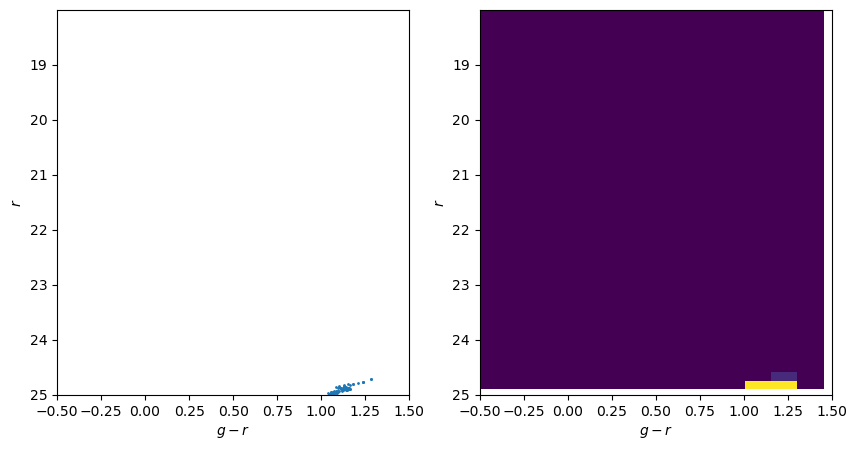

Total number of stars in background CMD
29.391330056754665


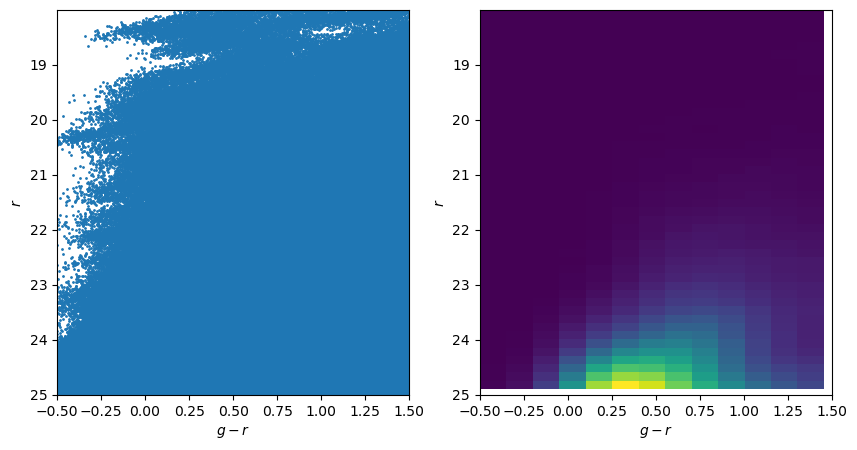

In [9]:
#Creates CMDs
objcmd = mf.mk_norm_objcmd_gd(field, signal_file, rmaglim=rmaglim, plot=True)   
backcmd = mf.mk_norm_backcmd(field, catalog, rmaglim=rmaglim, plot=True, pix=pix)

x min  -34.37746770784939
x max  34.37746770784939
y min  -34.37746770784939
y max  34.37746770784939


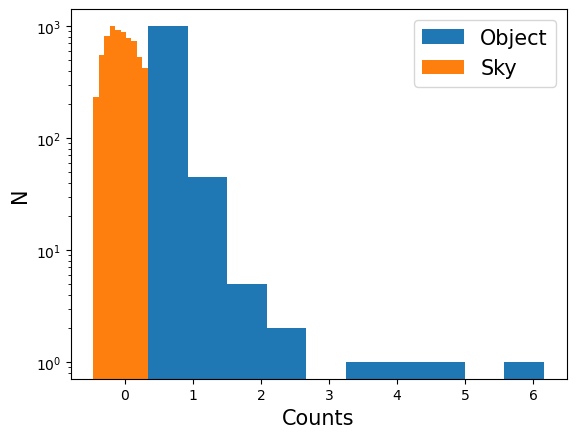

Sigma in smoothed stellar counts 0.19511351281565828
Mean in smoothed stellar counts -0.06403417239722556


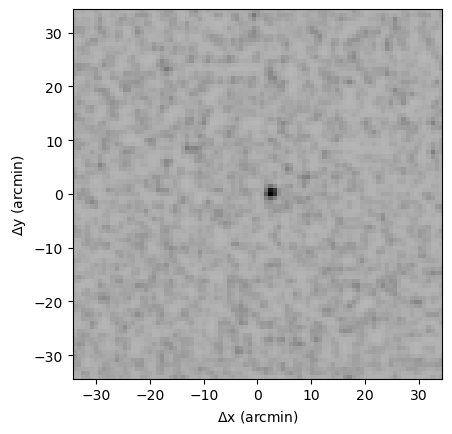

Successful run!
x min  -34.37746770784939
x max  34.37746770784939
y min  -34.37746770784939
y max  34.37746770784939


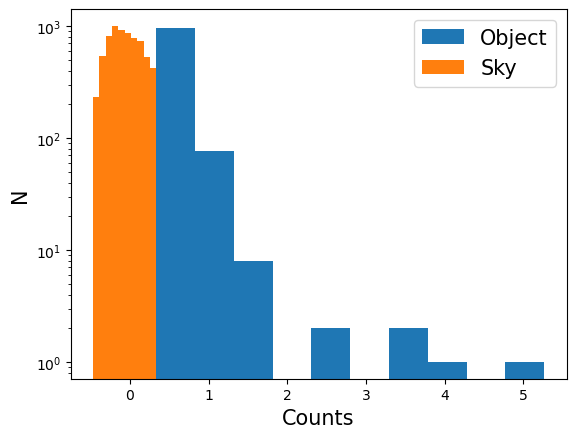

Sigma in smoothed stellar counts 0.1945440379911586
Mean in smoothed stellar counts -0.06426668576443288


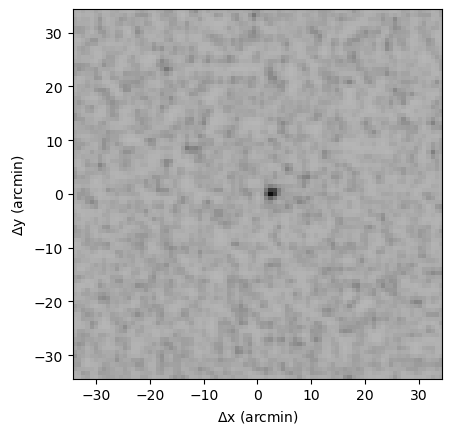

Successful run!


In [10]:
#MFA
for i in range(len(dec)):
            
    #First, load in data
    d = dec[i] 
    a = azi[i]

    #Third, run MFA
    
    save_path = f"/home/giantsid/MAP/matched_filter/mf_data/bg_added_catalogs/{new_str}/{box}_{num}/bg_{box}_{num}_d={d}_a={a}.fits"
    second_save_path = f"/home/giantsid/MAP/matched_filter/mf_data/mf_catalogs/{new_str}/{box}_{num}/mf_{box}_{num}_d={d}_a={a}_pix={numpix}.fits"
    
    mf.matched_filter_ani(objcmd, backcmd, second_save_path,
        field=field, 
        catalog=save_path,
        plot=True, rmaglim = rmaglim, pix=pix, pdist=pdist*60)
    print("Successful run!")